In [1]:
import os
from pathlib import Path

try:
    from occultence import *
except:
    os.chdir("../..")
    from occultence import *
data_dir = "../../Data"
    
import occultence
occultence.version()

'0.5.8'

(0.99, 1.015)

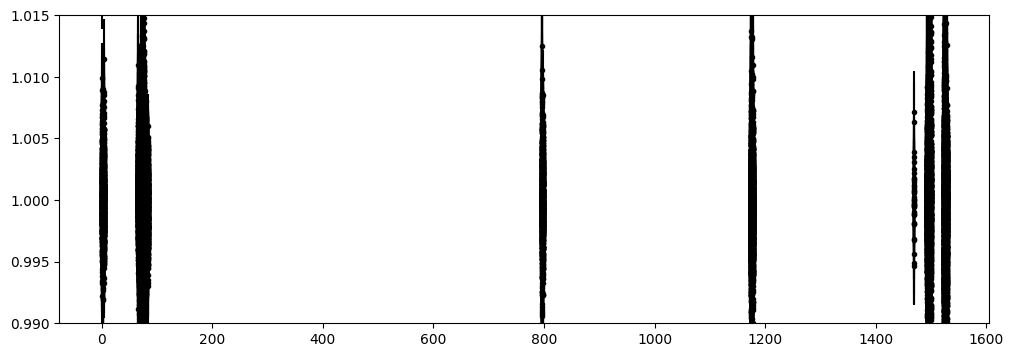

In [2]:
pre_bin = False

all_files = glob.glob(f"{data_dir}/file_*")
all_stars = pd.read_csv(f"{data_dir}/star_info.csv")

#select star/lightcurve to analyse
file_to_use = all_files[0]
file_stem = Path(file_to_use).stem

#get light curve of selected star
data = pd.read_csv(file_to_use)

t = data["bjd"].values - data["bjd"].values[0]
f = data["diff_flux_use"].values
ferr = data["diff_error"].values

#get stellar parameters
star_info = all_stars[all_stars["TARGET"]==file_stem]

R_star = star_info["RAD"].values[0]
M_star = star_info["MASS"].values[0]
T_star = star_info["TEFF"].values[0]

# f *= np.linspace(1,1.01, len(t)) # add a linear trend for the GP to remove
plt.figure(figsize=(12,4))
plt.errorbar(t,f,ferr,fmt='k.')
plt.ylim(0.99,1.015)

In [3]:
targ = LightCurve(name = "secondLC",
                  time = t,
                  flux = f,
                  uncertainty = np.abs(ferr),
                  telescope = "None",
                  filter="None",
                  metadata={'R_star':R_star*u.R_sun, 'M_star':M_star*u.M_sun,
                           'Teff':T_star * u.K})

🤖⚠ Warning! The time array is not an astropy.Time object, therefore there is no info about the 
format or scale.
We will assume that it is JD and TDB from here on! ⚠🤖



In [4]:
targ_with_transit = targ.inject_transit(per=2.55*u.d, 
                                        epoch=0.025 * u.d, 
                                        inc=90 * u.degree, 
                                        rp=1 * u.R_earth, 
                                        ld=[0.3,0.3])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='transit_model'>, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: xlabel='Time [d]'>], dtype=object)

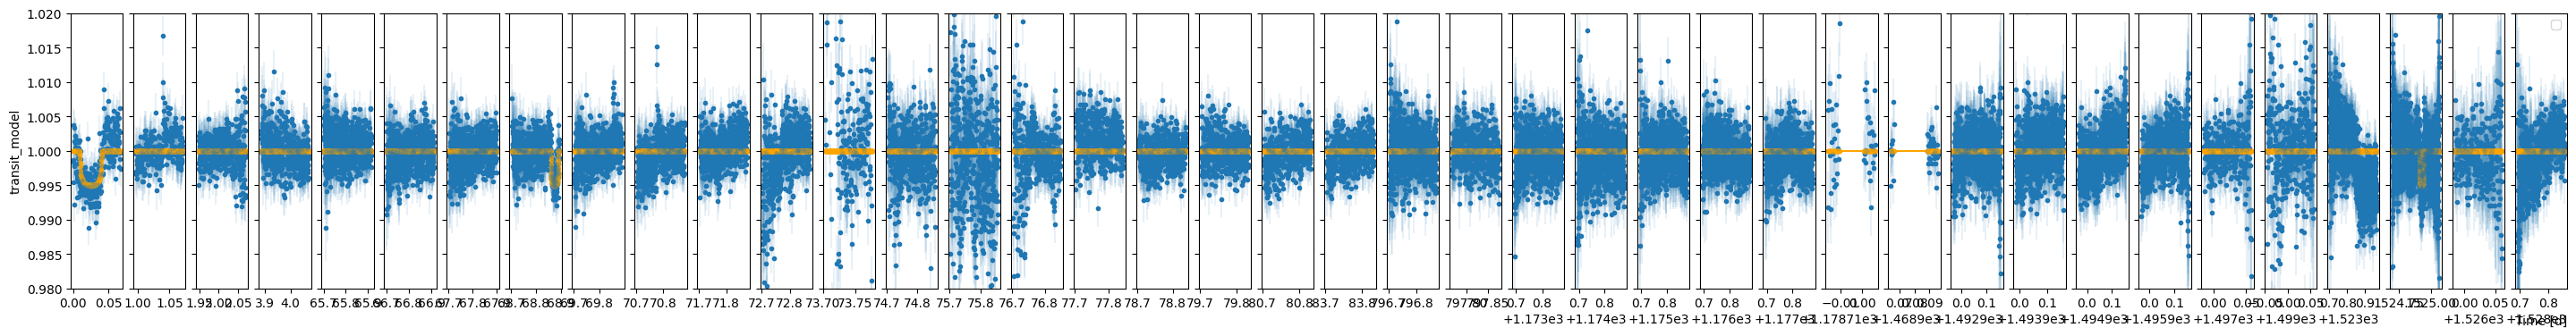

In [5]:
ax=targ_with_transit.plot()
targ_with_transit.plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")

In [6]:
per=2.55*u.d
epoch=0.025 * u.d
inc=90 * u.degree
rp=1 * u.R_earth
ld=[0.3,0.3]

planets = targ_with_transit.create_lots_of_transit_params(nfake=1, 
                                                          minimum_planet_radius=rp, 
                                                          maximum_planet_radius=rp,
                                                          minimum_period=per, 
                                                          maximum_period=per,
                                                        )
planets

,logP,phase,cosi,r_p,depth,duration,epoch,a,a_Rs,injected,...,rec_depth,rec_duration,rec_epoch,run,snr,target,r_s,m_s,teff,spt
0,0.40654,0.369173,0.000306,1.0,0.004288274427155711,0.032179,0.94139,3.763530784156991 solRad,26.882362743978504,0.0,...,0.0,0.0,0.0,0.0,0.0,secondLC_inject,0.14 solRad,0.11 solMass,None,None


In [10]:
# def bin(self, dt, bin_func=np.nanmedian, **kw):
#     """Fast binning using pure NumPy operations with unit support."""
#     cuts, _ = self.split_time(split=self.split_by)
    
#     binned_lc = self._create_copy()
#     binned_lc.timelike = {}
    
#     # Process each segment
#     all_bin_edges = []
#     all_bin_centers = []
#     all_bin_sizes = []
#     binned_data = {key: [] for key in self.timelike.keys() if key != 'time'}
    
#     for i in range(len(cuts) - 1):
#         start_idx, end_idx = cuts[i], cuts[i + 1]
        
#         # Extract time values for this segment
#         time_data = self.timelike['time'][start_idx:end_idx]
        
#         # Handle different time types and extract numeric values + units
#         if isinstance(time_data, astropy.time.core.Time):
#             # For Time objects, work in days (MJD scale)
#             time_vals = time_data.mjd
#             time_unit = 'mjd'
            
#             # Convert dt to days if it has units
#             if hasattr(dt, 'to'):
#                 dt_val = dt.to(astropy.units.day).value
#             elif isinstance(dt, astropy.time.TimeDelta):
#                 dt_val = dt.to(astropy.units.day).value
#             else:
#                 dt_val = dt  # Assume already in days
#         else:
#             # For Quantity or regular arrays
#             if hasattr(time_data, 'unit'):
#                 time_vals = time_data.value
#                 time_unit = time_data.unit
                
#                 # Convert dt to same units
#                 if hasattr(dt, 'to'):
#                     dt_val = dt.to(time_unit).value
#                 else:
#                     dt_val = dt  # Assume already in correct units
#             else:
#                 time_vals = time_data
#                 time_unit = None
#                 dt_val = dt if not hasattr(dt, 'value') else dt.value
        
#         # Create bins for this segment
#         t_min, t_max = np.nanmin(time_vals), np.nanmax(time_vals)
#         bin_edges = np.arange(t_min, t_max + dt_val, dt_val)
        
#         # Digitize: assign each time point to a bin
#         bin_indices = np.digitize(time_vals, bin_edges) - 1
        
#         # Find which bins actually have data
#         unique_bins = np.unique(bin_indices)
#         unique_bins = unique_bins[(unique_bins >= 0) & (unique_bins < len(bin_edges) - 1)]
        
#         # Store bin info (keep as plain arrays, will add units at end)
#         seg_bin_edges = bin_edges[unique_bins]
#         seg_bin_sizes = np.full(len(unique_bins), dt_val)
#         seg_bin_centers = seg_bin_edges + 0.5 * dt_val
        
#         all_bin_edges.append(seg_bin_edges)
#         all_bin_centers.append(seg_bin_centers)
#         all_bin_sizes.append(seg_bin_sizes)
        
#         # Bin each data column
#         for key in binned_data.keys():
#             data = self.timelike[key][start_idx:end_idx]
            
#             # Handle different data types
#             if isinstance(data, astropy.time.core.Time):
#                 # For Time objects, just take first value in each bin
#                 binned_vals = []
#                 for bin_idx in unique_bins:
#                     mask = bin_indices == bin_idx
#                     if np.any(mask):
#                         binned_vals.append(data[mask][0])
#                 binned_data[key].append(astropy.time.Time(binned_vals))
#                 continue
            
#             # Extract numeric values
#             has_unit = hasattr(data, 'unit')
#             if isinstance(data, astropy.table.column.MaskedColumn):
#                 data_vals = data.filled(np.nan)
#             elif hasattr(data, 'value'):
#                 data_vals = data.value
#             else:
#                 data_vals = data
            
#             # Apply binning function to each bin
#             binned_vals = np.empty(len(unique_bins))
#             for j, bin_idx in enumerate(unique_bins):
#                 mask = bin_indices == bin_idx
#                 if np.any(mask):
#                     binned_vals[j] = bin_func(data_vals[mask])
#                 else:
#                     binned_vals[j] = np.nan
            
#             # Restore units if original had them
#             if has_unit:
#                 binned_vals = binned_vals * data.unit
            
#             binned_data[key].append(binned_vals)
    
#     # Concatenate all segments and restore units/types
#     bin_edges_concat = np.concatenate(all_bin_edges)
#     bin_sizes_concat = np.concatenate(all_bin_sizes)
#     bin_centers_concat = np.concatenate(all_bin_centers)
    
#     # Restore appropriate type for time data
#     time_data = self.timelike['time']
#     if isinstance(time_data, astropy.time.core.Time):
#         binned_lc.timelike['time_bin_start'] = astropy.time.Time(bin_edges_concat, format='mjd')
#         binned_lc.timelike['time_bin_size'] = bin_sizes_concat * astropy.units.day
#         binned_lc.timelike['time'] = astropy.time.Time(bin_centers_concat, format='mjd')
#     elif hasattr(time_data, 'unit'):
#         binned_lc.timelike['time_bin_start'] = bin_edges_concat * time_unit
#         binned_lc.timelike['time_bin_size'] = bin_sizes_concat * time_unit
#         binned_lc.timelike['time'] = bin_centers_concat * time_unit
#     else:
#         binned_lc.timelike['time_bin_start'] = bin_edges_concat
#         binned_lc.timelike['time_bin_size'] = bin_sizes_concat
#         binned_lc.timelike['time'] = bin_centers_concat
    
#     # Concatenate binned data
#     for key, values in binned_data.items():
#         if len(values) > 0 and isinstance(values[0], astropy.time.core.Time):
#             binned_lc.timelike[key] = astropy.time.Time(np.concatenate([v.value for v in values]))
#         elif len(values) > 0 and hasattr(values[0], 'unit'):
#             # Concatenate quantities with units
#             unit = values[0].unit
#             binned_lc.timelike[key] = np.concatenate([v.value for v in values]) * unit
#         else:
#             binned_lc.timelike[key] = np.concatenate(values)
    
#     binned_lc._set_name(binned_lc.name + "_bin")
#     return binned_lc


# def bin_fast_vectorized(self, dt, bin_func=np.nanmedian, **kw):
#     """Ultra-fast vectorized binning with unit support."""
#     cuts, _ = self.split_time(split=self.split_by)
    
#     binned_lc = self._create_copy()
#     binned_lc.timelike = {}
    
#     all_results = []
#     time_type_info = None  # Store time type info from first segment
    
#     for i in range(len(cuts) - 1):
#         start_idx, end_idx = cuts[i], cuts[i + 1]
        
#         # Extract time values
#         time_data = self.timelike['time'][start_idx:end_idx]
        
#         # Handle units and extract numeric values
#         if isinstance(time_data, astropy.time.core.Time):
#             time_vals = time_data.mjd
#             if i == 0:
#                 time_type_info = ('time', time_data.format, time_data.scale)
#             dt_val = dt.to(astropy.units.day).value if hasattr(dt, 'to') else dt
#         elif hasattr(time_data, 'unit'):
#             time_vals = time_data.value
#             if i == 0:
#                 time_type_info = ('quantity', time_data.unit)
#             dt_val = dt.to(time_data.unit).value if hasattr(dt, 'to') else dt
#         else:
#             time_vals = time_data
#             if i == 0:
#                 time_type_info = ('plain', None)
#             dt_val = dt if not hasattr(dt, 'value') else dt.value
        
#         # Create bins
#         t_min, t_max = np.nanmin(time_vals), np.nanmax(time_vals)
#         bin_edges = np.arange(t_min, t_max + dt_val, dt_val)
#         bin_indices = np.digitize(time_vals, bin_edges) - 1
        
#         # Create temporary dataframe with numeric values only
#         df_dict = {'bin': bin_indices}
#         col_units = {}  # Track units for each column
        
#         for key in self.timelike.keys():
#             if key == 'time':
#                 continue
#             data = self.timelike[key][start_idx:end_idx]
#             if isinstance(data, astropy.time.core.Time):
#                 continue  # Skip Time objects
            
#             if hasattr(data, 'unit'):
#                 col_units[key] = data.unit
#                 data_vals = data.value
#             elif isinstance(data, astropy.table.column.MaskedColumn):
#                 data_vals = data.filled(np.nan)
#                 if hasattr(data, 'value'):
#                     data_vals = data_vals if not hasattr(data_vals, 'value') else data_vals.value
#             else:
#                 data_vals = data.value if hasattr(data, 'value') else data
            
#             df_dict[key] = data_vals
        
#         df = pd.DataFrame(df_dict)
        
#         # Group and aggregate
#         if bin_func == np.nanmedian:
#             grouped = df.groupby('bin').median()
#         elif bin_func == np.nanmean or bin_func == np.mean:
#             grouped = df.groupby('bin').mean()
#         else:
#             grouped = df.groupby('bin').agg(lambda x: bin_func(x.values))
        
#         # Extract results
#         valid_bins = grouped.index.values
#         valid_bins = valid_bins[(valid_bins >= 0) & (valid_bins < len(bin_edges) - 1)]
        
#         result = {
#             'time_bin_start': bin_edges[valid_bins],
#             'time_bin_size': np.full(len(valid_bins), dt_val),
#             'time': bin_edges[valid_bins] + 0.5 * dt_val,
#             '_col_units': col_units  # Store units metadata
#         }
        
#         for key in grouped.columns:
#             result[key] = grouped.loc[valid_bins, key].values
        
#         all_results.append(result)
            
#     # Concatenate all segments and restore types
#     col_units = all_results[0].get('_col_units', {})
    
#     for key in ['time_bin_start', 'time_bin_size', 'time']:
#         concat_vals = np.concatenate([r[key] for r in all_results])
        
#         # Restore appropriate type
#         if time_type_info[0] == 'time':
#             if key == 'time_bin_size':
#                 binned_lc.timelike[key] = concat_vals * astropy.units.day
#             else:
#                 binned_lc.timelike[key] = astropy.time.Time(concat_vals, format='mjd')
#         elif time_type_info[0] == 'quantity':
#             binned_lc.timelike[key] = concat_vals * time_type_info[1]
#         else:
#             binned_lc.timelike[key] = concat_vals
    
#     # Concatenate data columns with units
#     for key in all_results[0].keys():
#         if key in ['time_bin_start', 'time_bin_size', 'time', '_col_units']:
#             continue
        
#         concat_vals = np.concatenate([r[key] for r in all_results])
        
#         if key in col_units:
#             binned_lc.timelike[key] = concat_vals * col_units[key]
#         else:
#             binned_lc.timelike[key] = concat_vals
    
#     binned_lc._set_name(binned_lc.name + "_bin")
#     return binned_lc

start_time = time.perf_counter()
targ_bin = targ.bin(dt=20*u.minute)
end_time = time.perf_counter()
time_used = end_time - start_time
print(f"time used: {time_used:.6f} seconds")

# # from occultence.binning import bin_fast_vectorized
# start_time = time.perf_counter()
# targ_bin2 = bin_fast_vectorized(targ, dt=2*u.minute)
# end_time = time.perf_counter()
# time_used = end_time - start_time
# print(f"time used: {time_used:.6f} seconds")

time used: 0.045284 seconds


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


array([<Axes: ylabel='flux'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='Time [d]'>],
      dtype=object)

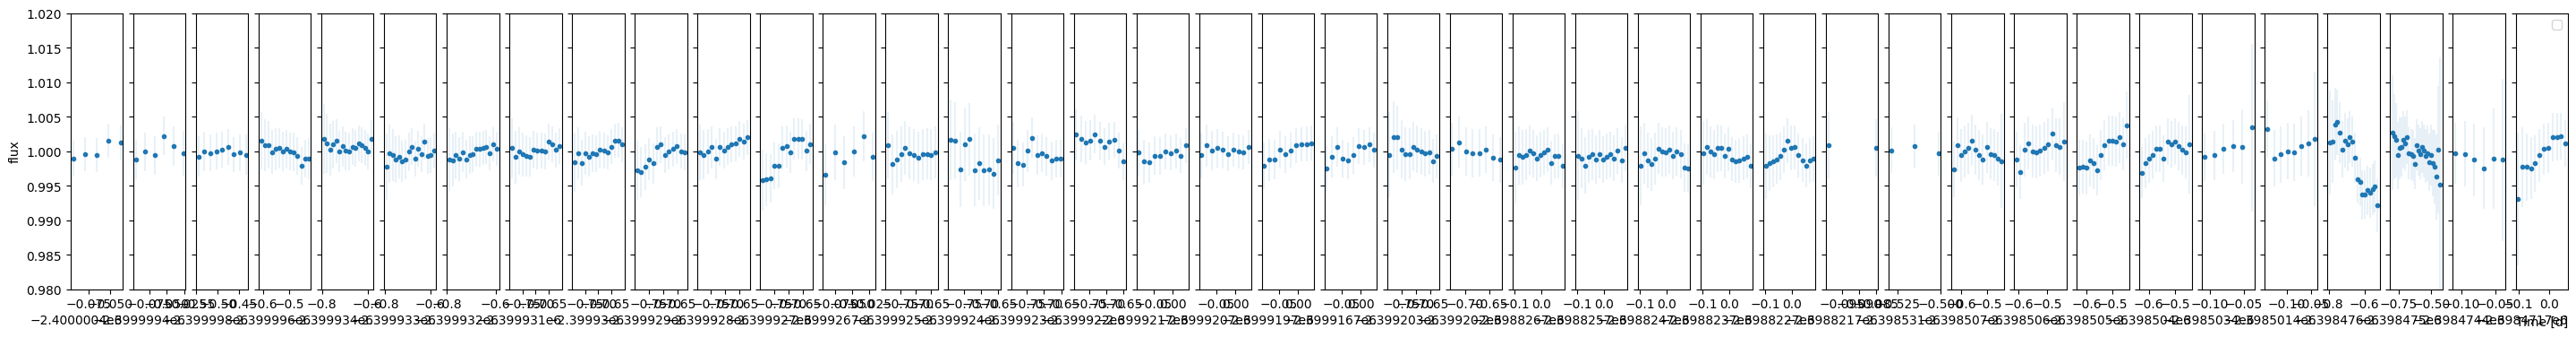

In [11]:
targ_bin.plot()
# targ_bin2.plot()

1/5...


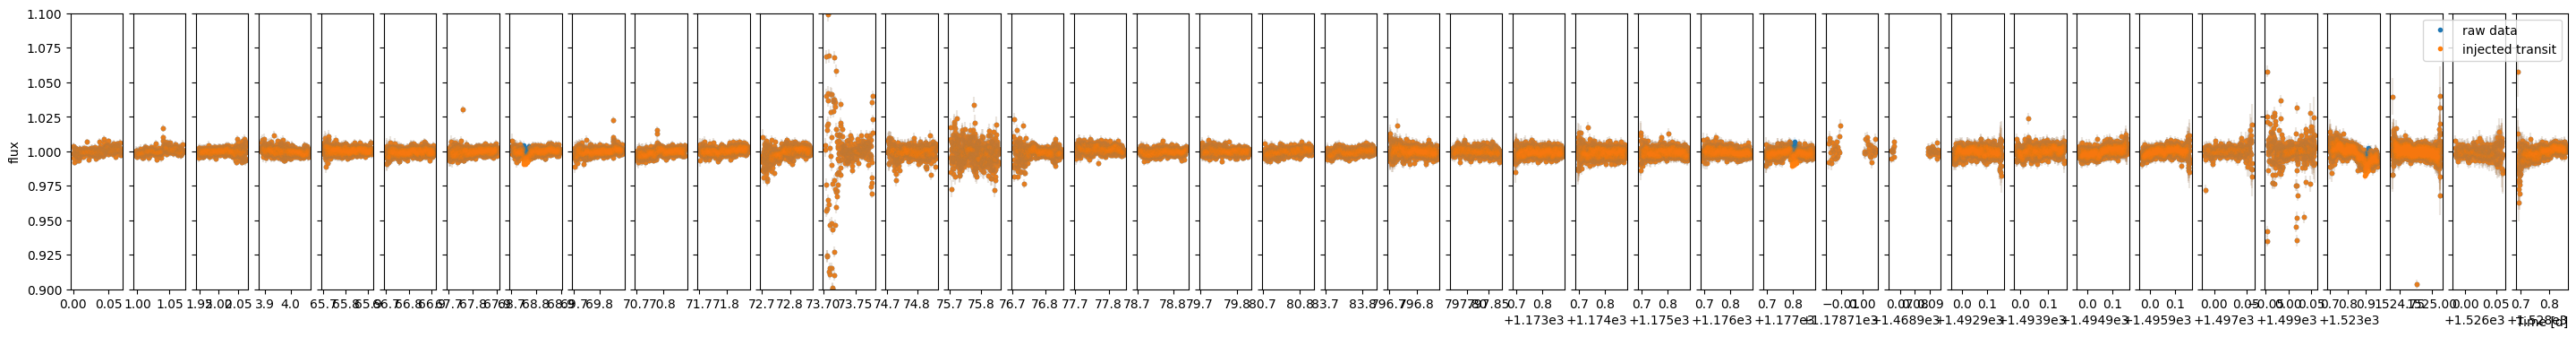

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.06192224335441638% of data is flagged as cosmics ⚡.
            
Time to clean LC: 10.064033031463623


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            There are 5 flare candidates with >30.0 s over 3$\sigma$
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to remove flares: 37.46672987937927
Running BLS Search
Number of Periods Checked:  2921580269
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0
No transits detected!
Time to BLS before detrending: 443.51142716407776


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-5.6946777  -6.46014147 -2.30258509]
Initial Params: AMP =  0.0015645743586883607 , SQEXP=  0.10000000000000002 , JITTER =  0.0033638211572522506
Initial ln-likelihood: 1537.54
Fitted GP HPs: [-29.00518103 -18.37332311   6.7573999 ]
Fitted Params: AMP =  1.0484969175692698e-08 , SQEXP=  860.4021526441442 , JITTER =  2.530520917430583e-13
Final ln-likelihood: 3852.56


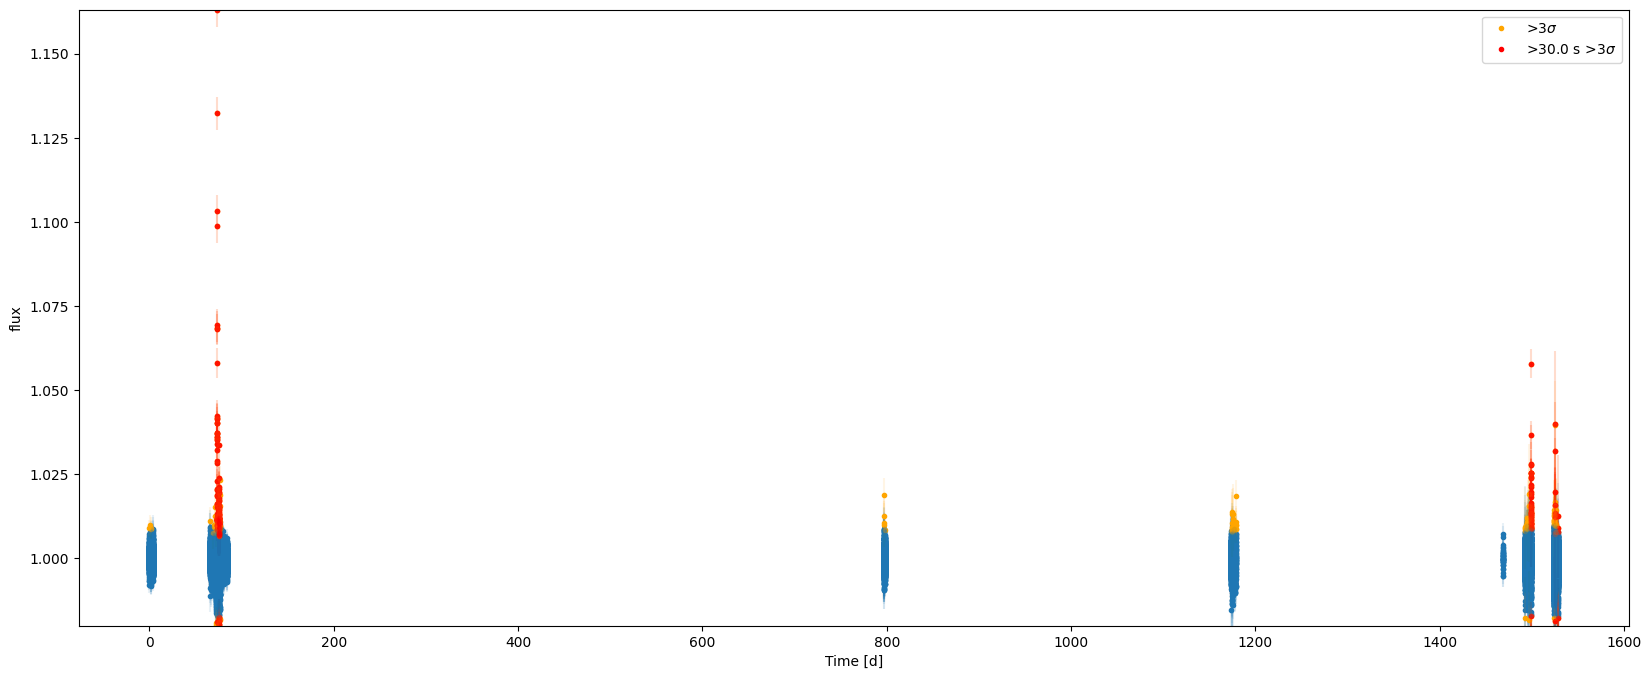

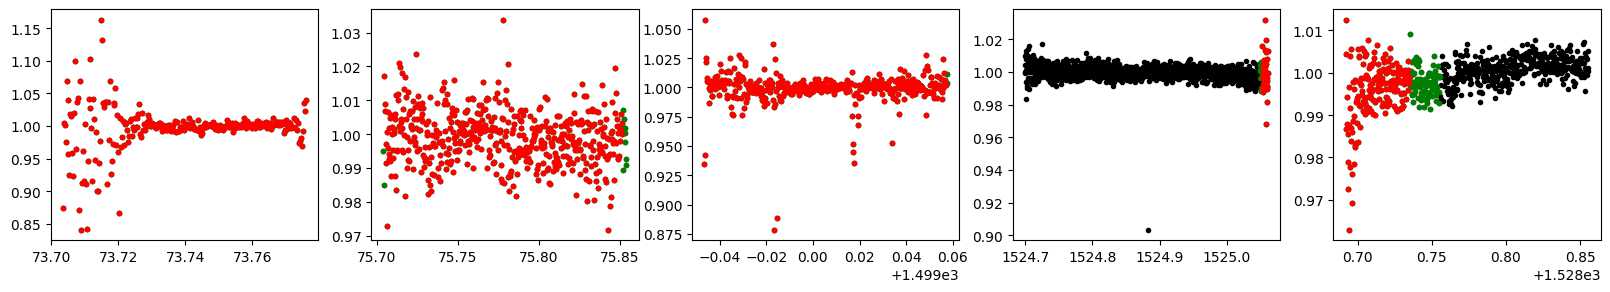

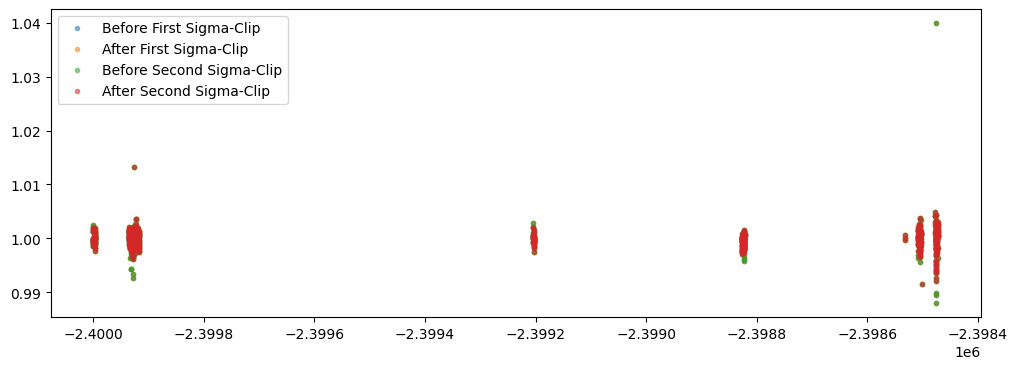

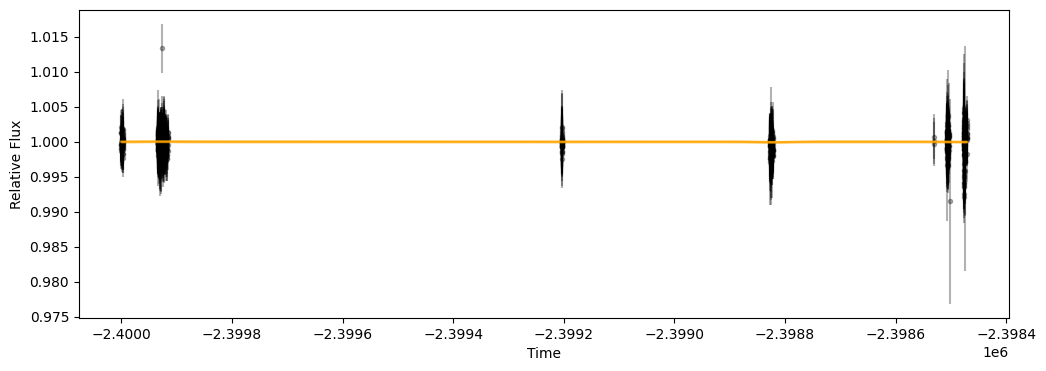

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 5.711392879486084


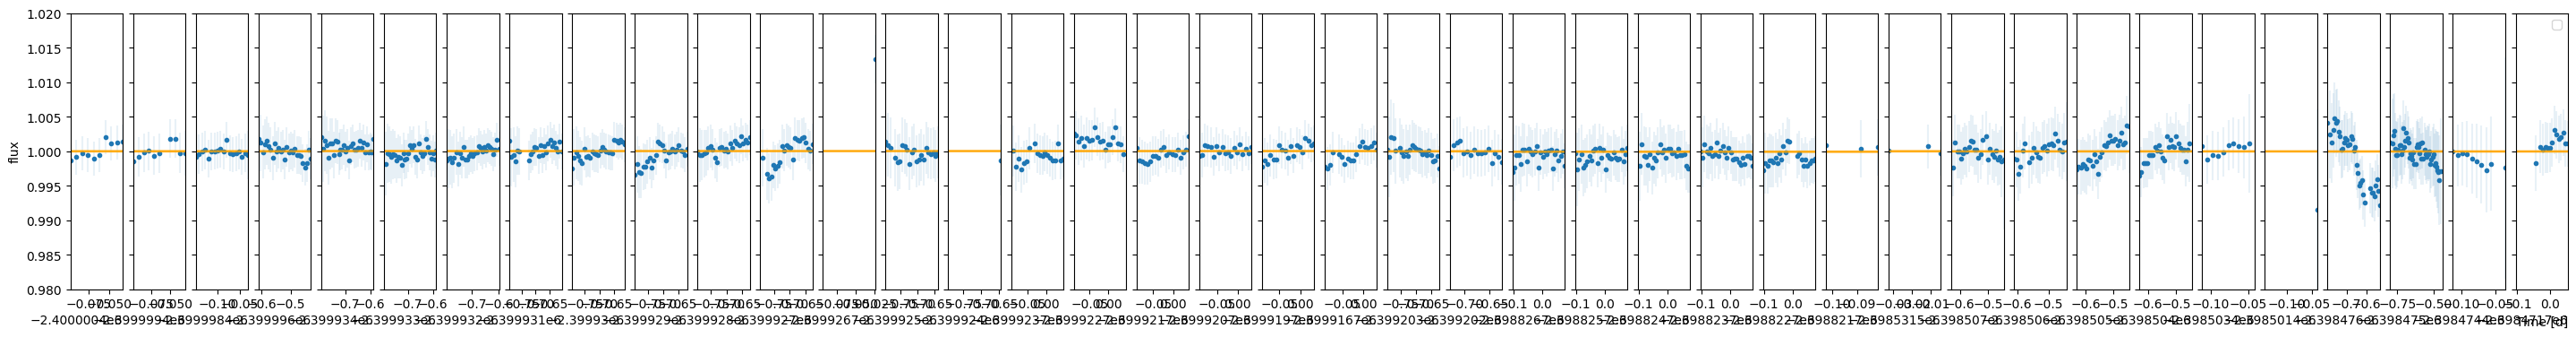

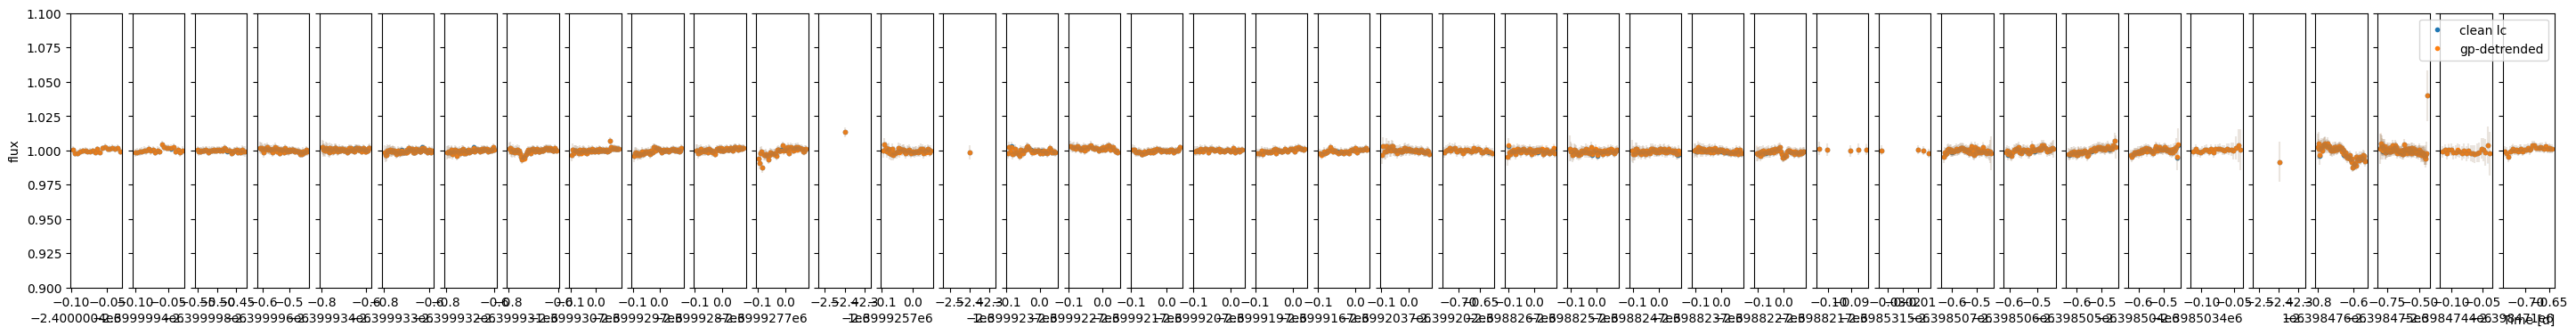

Running BLS Search
Number of Periods Checked:  2921593540
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0
No transits detected!
Time to BLS search: 396.1221649646759
No transit found!

2/5...


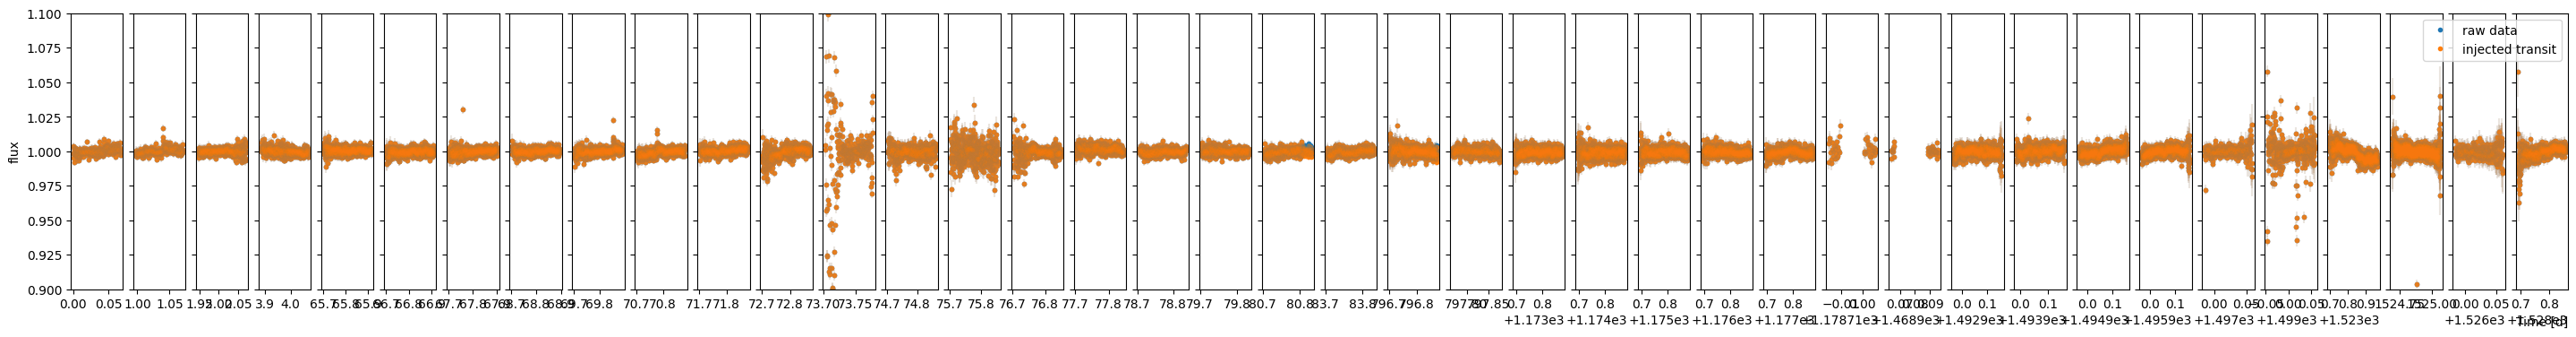

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.06192224335441638% of data is flagged as cosmics ⚡.
            
Time to clean LC: 7.860143184661865


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            There are 5 flare candidates with >30.0 s over 3$\sigma$
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to remove flares: 22.163673162460327
Running BLS Search
Number of Periods Checked:  2921580269
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0
No transits detected!
Time to BLS before detrending: 402.2383658885956


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-5.69528968 -6.45096534 -2.30258509]
Initial Params: AMP =  0.001578997168379618 , SQEXP=  0.10000000000000002 , JITTER =  0.0033617632094318744
Initial ln-likelihood: 1547.16
Fitted GP HPs: [-29.41986929 -17.93549718   2.78032649]
Fitted Params: AMP =  1.6244731765740152e-08 , SQEXP=  16.12428448252691 , JITTER =  1.6715259023430873e-13
Final ln-likelihood: 3874.72


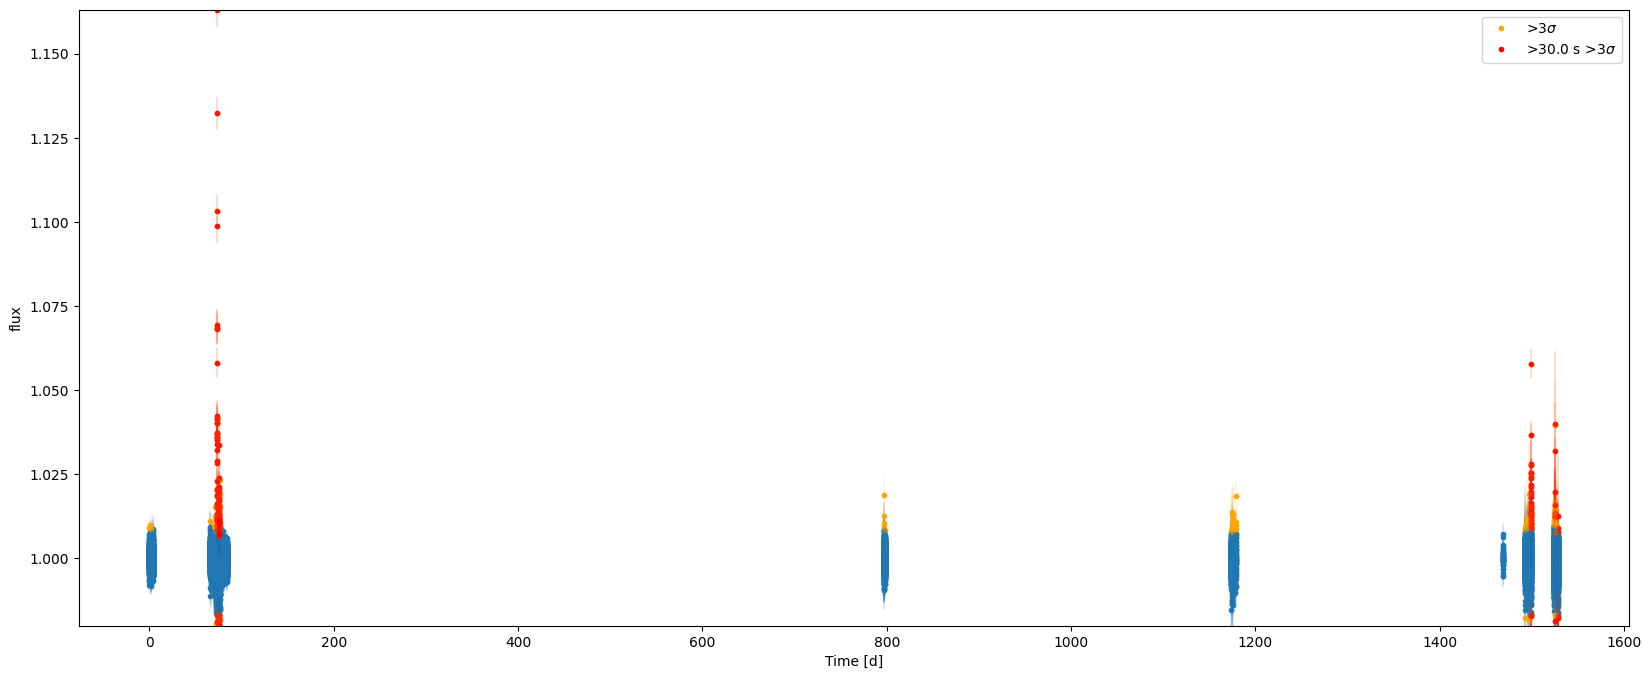

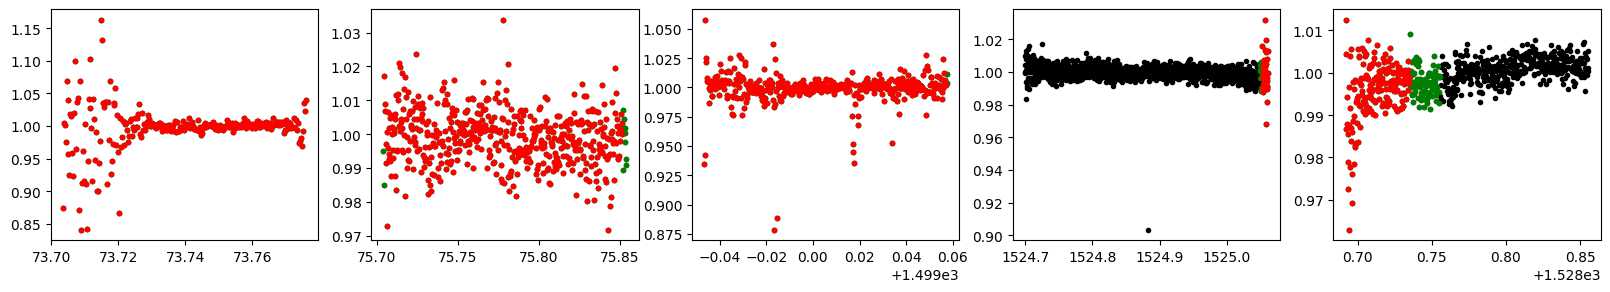

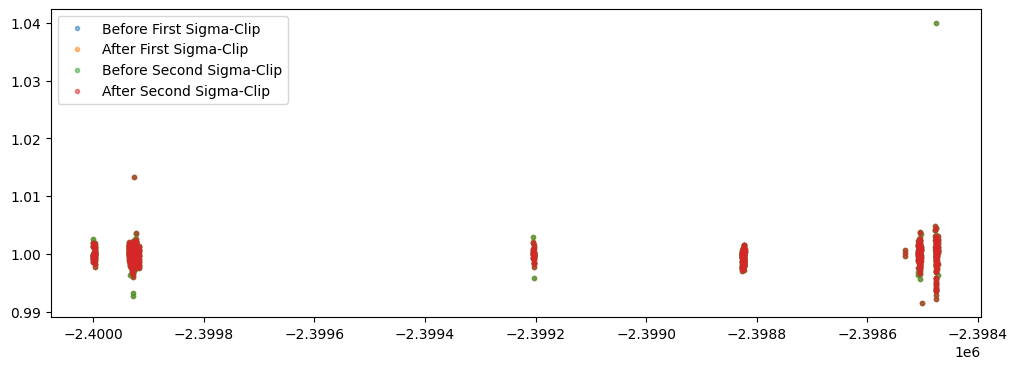

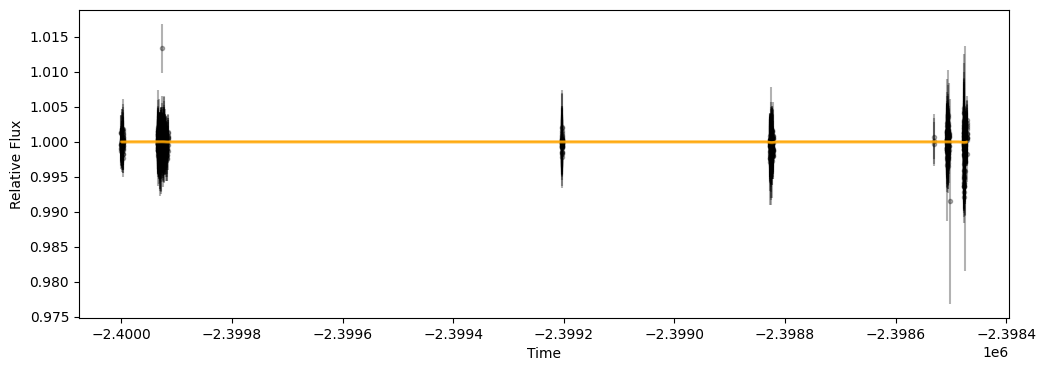

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 3.735063076019287


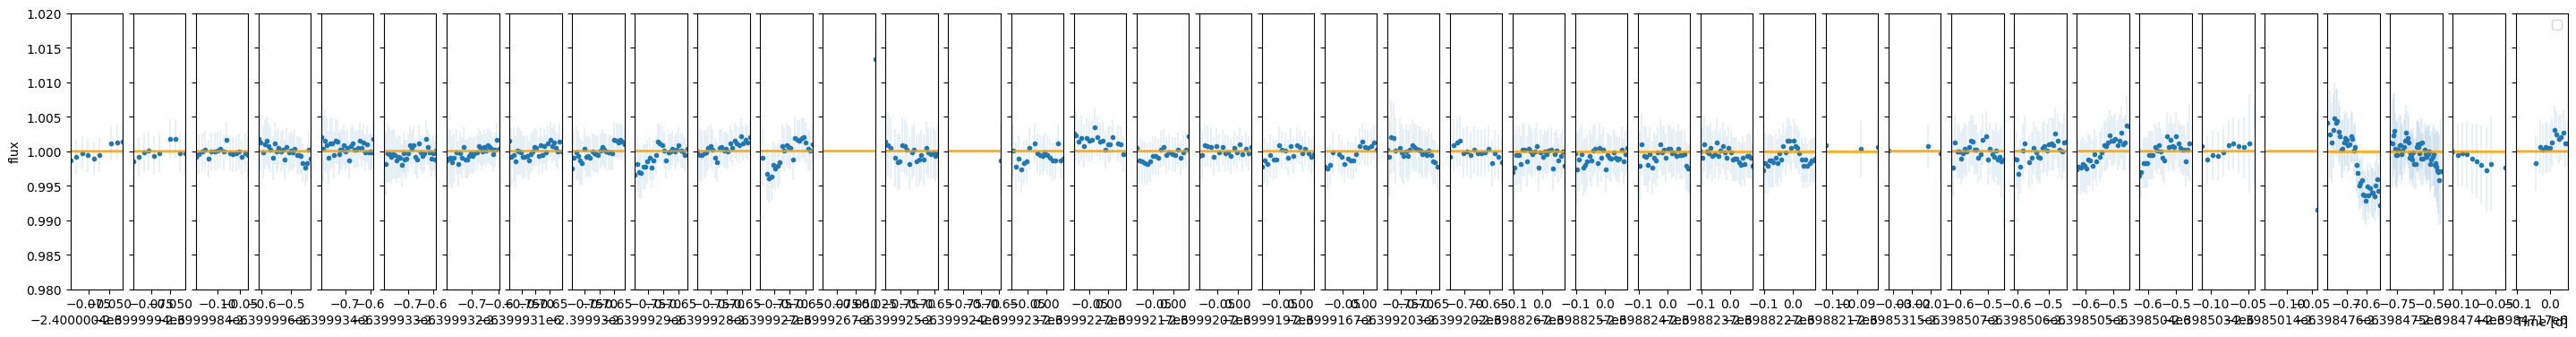

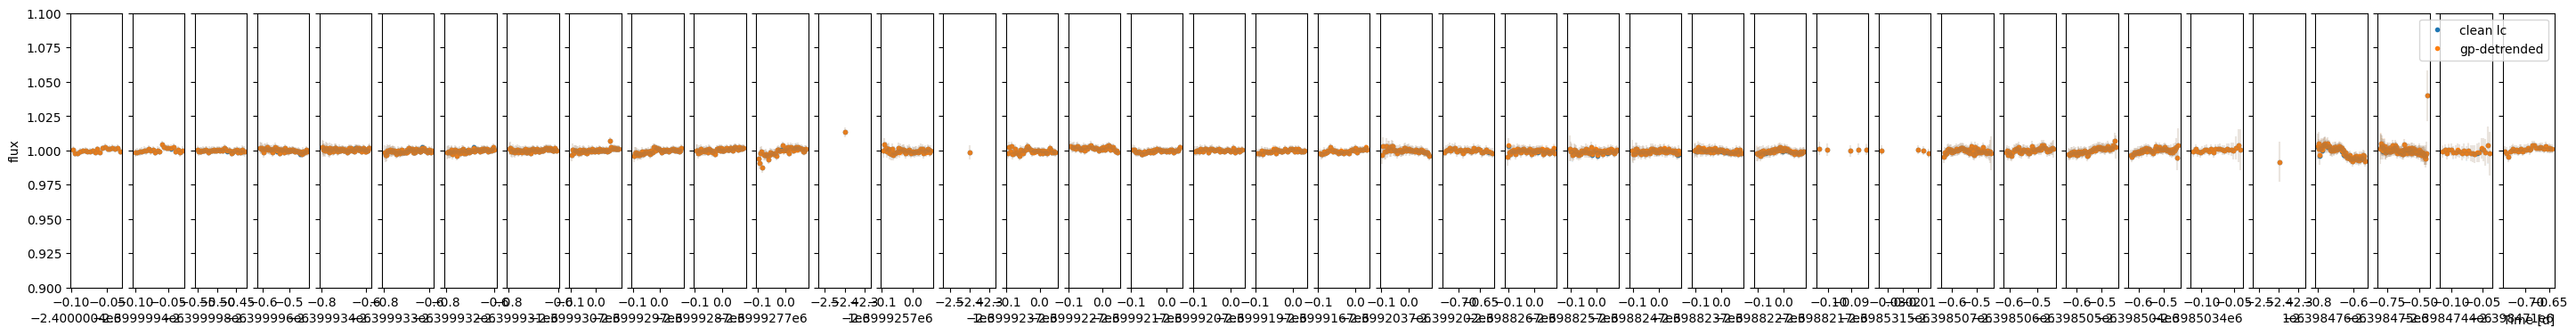

Running BLS Search
Number of Periods Checked:  2921593540
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0
No transits detected!
Time to BLS search: 394.1214609146118
No transit found!

3/5...


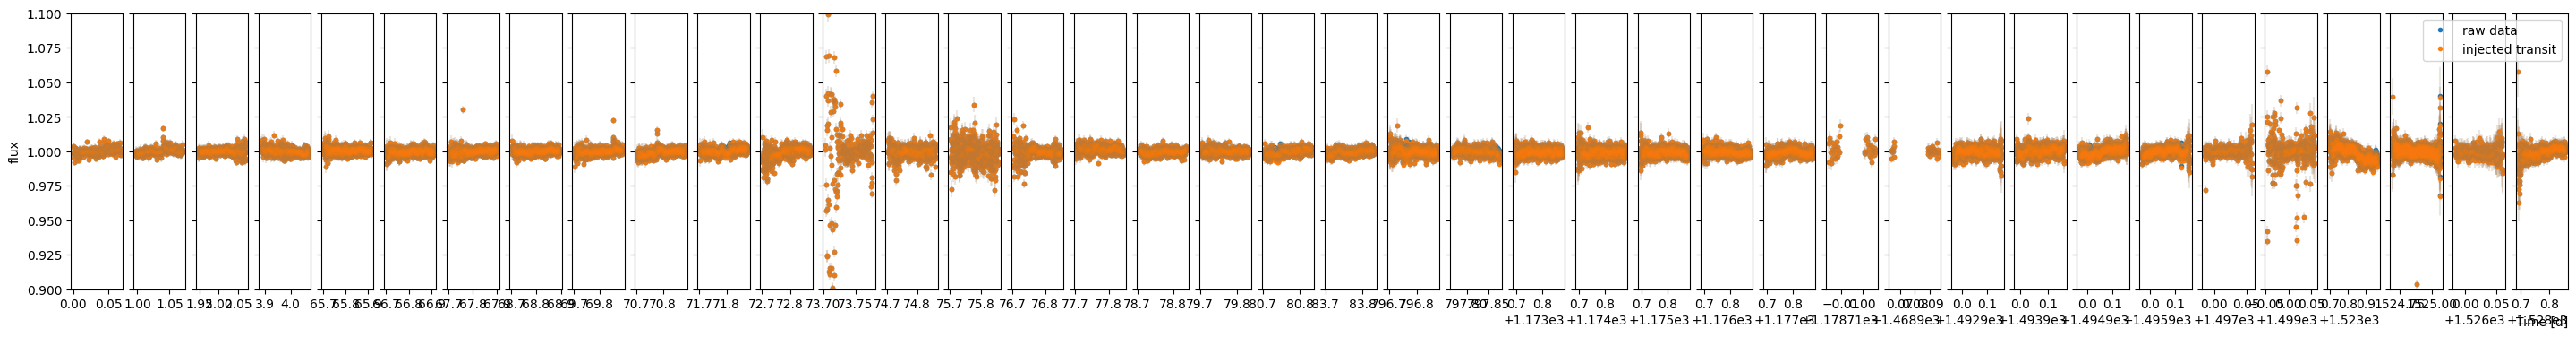

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.06192224335441638% of data is flagged as cosmics ⚡.
            
Time to clean LC: 7.359484910964966


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            There are 4 flare candidates with >30.0 s over 3$\sigma$
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to remove flares: 21.22043204307556
Running BLS Search
Number of Periods Checked:  2921580269
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0
No transits detected!
Time to BLS before detrending: 396.48195004463196


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  return function_base._ureduce(a, func=_nanmedian, keepdims=keepdims,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)


Fitting rotation with square-exponential GP...
Initial Parameter Vector:  [-5.69528968 -6.42324427 -2.30258509]
Initial Params: AMP =  0.0016233810037622593 , SQEXP=  0.10000000000000002 , JITTER =  0.0033617632094318744
Initial ln-likelihood: 1554.18
Fitted GP HPs: [-28.40342372 -17.852271     2.61515203]
Fitted Params: AMP =  1.765457292203128e-08 , SQEXP=  13.669294325234898 , JITTER =  4.619019647147658e-13
Final ln-likelihood: 3887.98


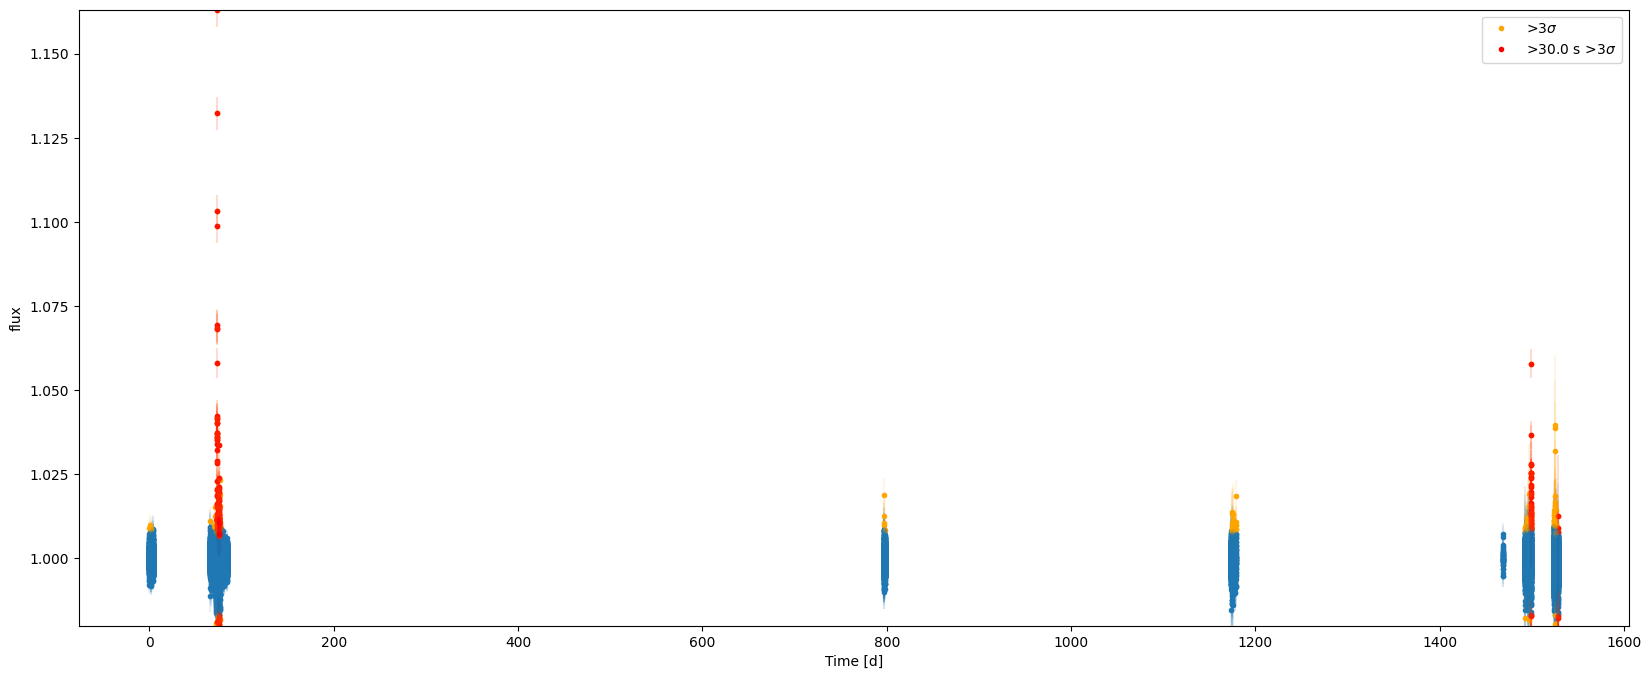

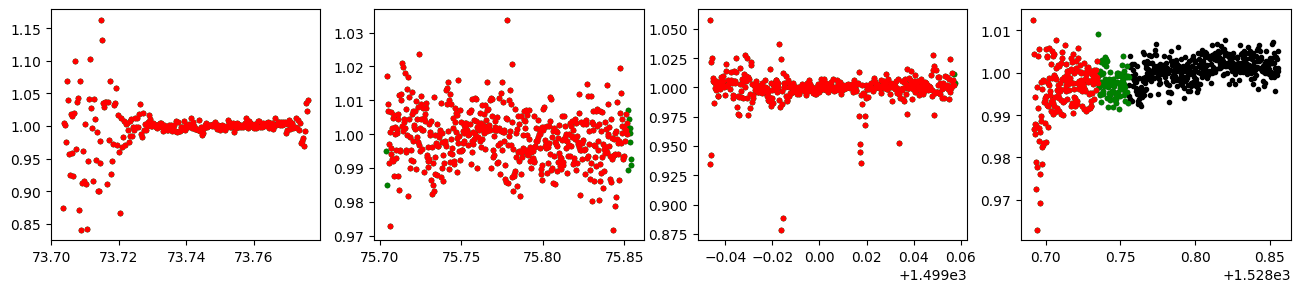

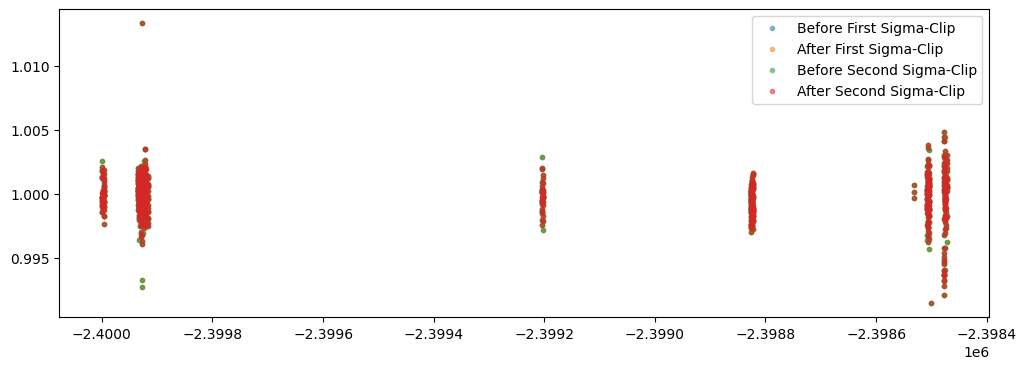

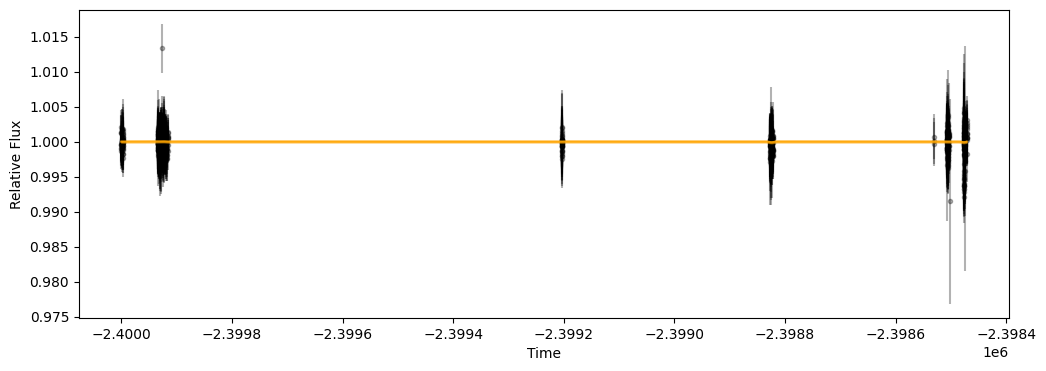

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to detrend: 4.573170900344849


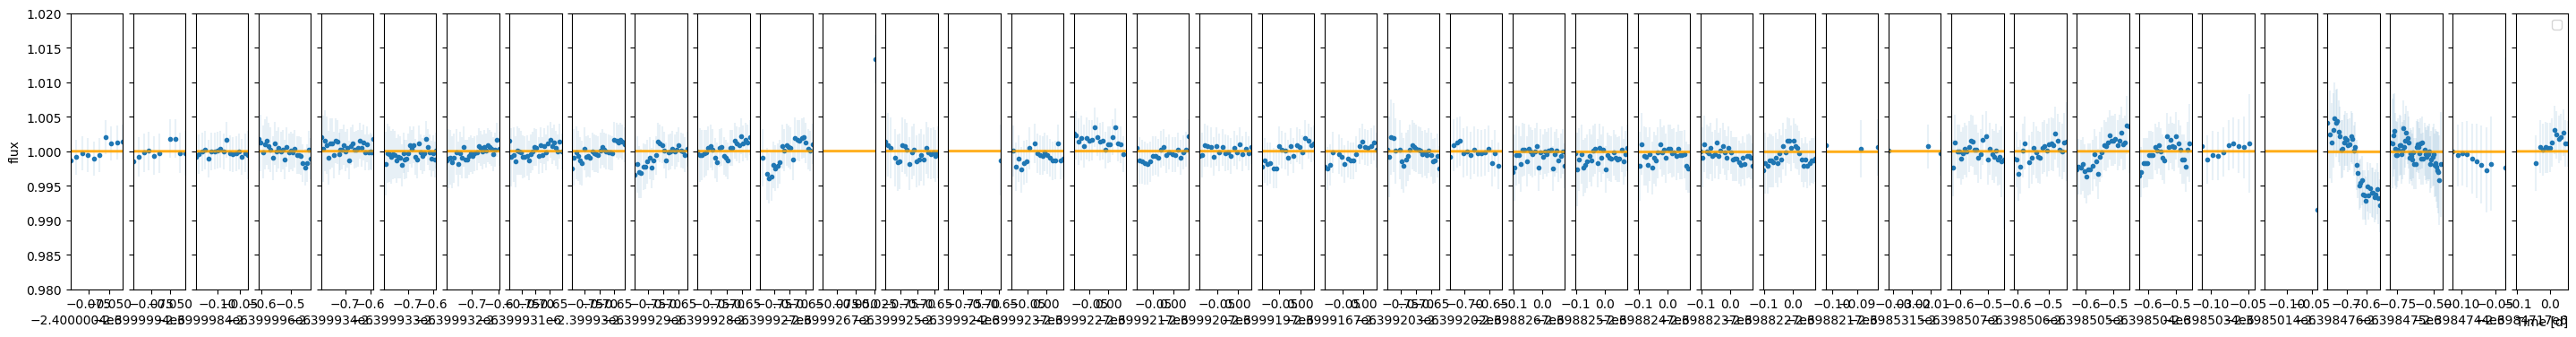

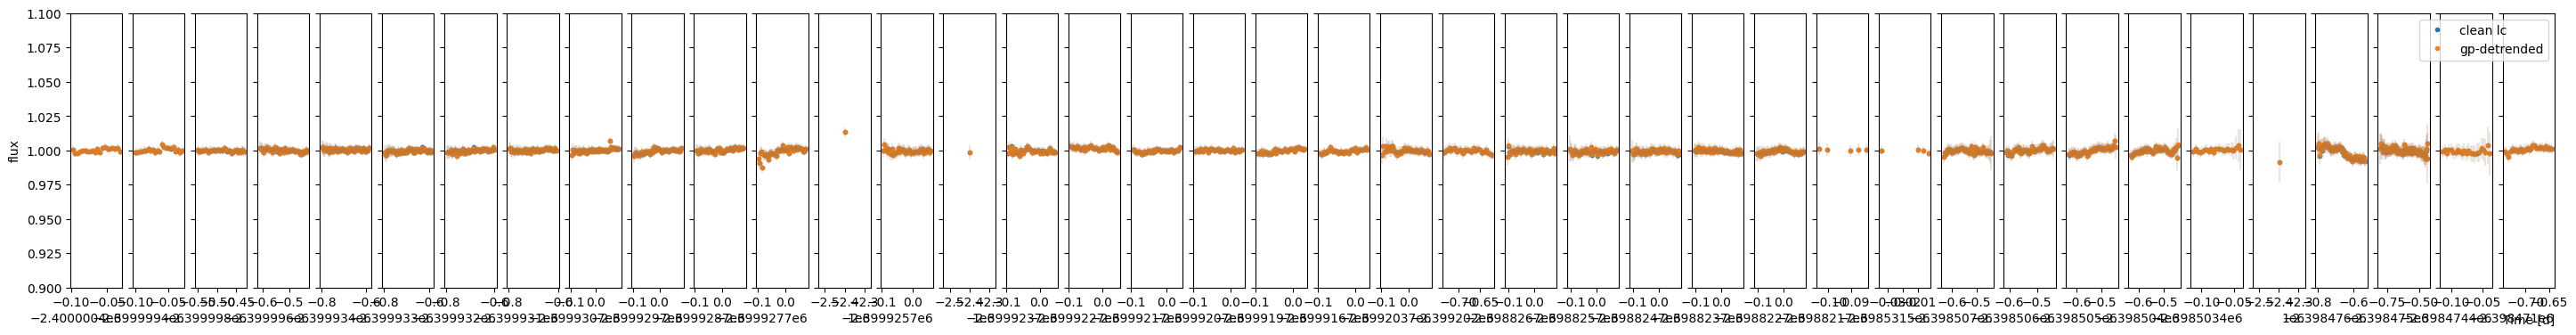

Running BLS Search
Number of Periods Checked:  2921593540
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0
No transits detected!
Time to BLS search: 394.0706830024719
No transit found!

4/5...


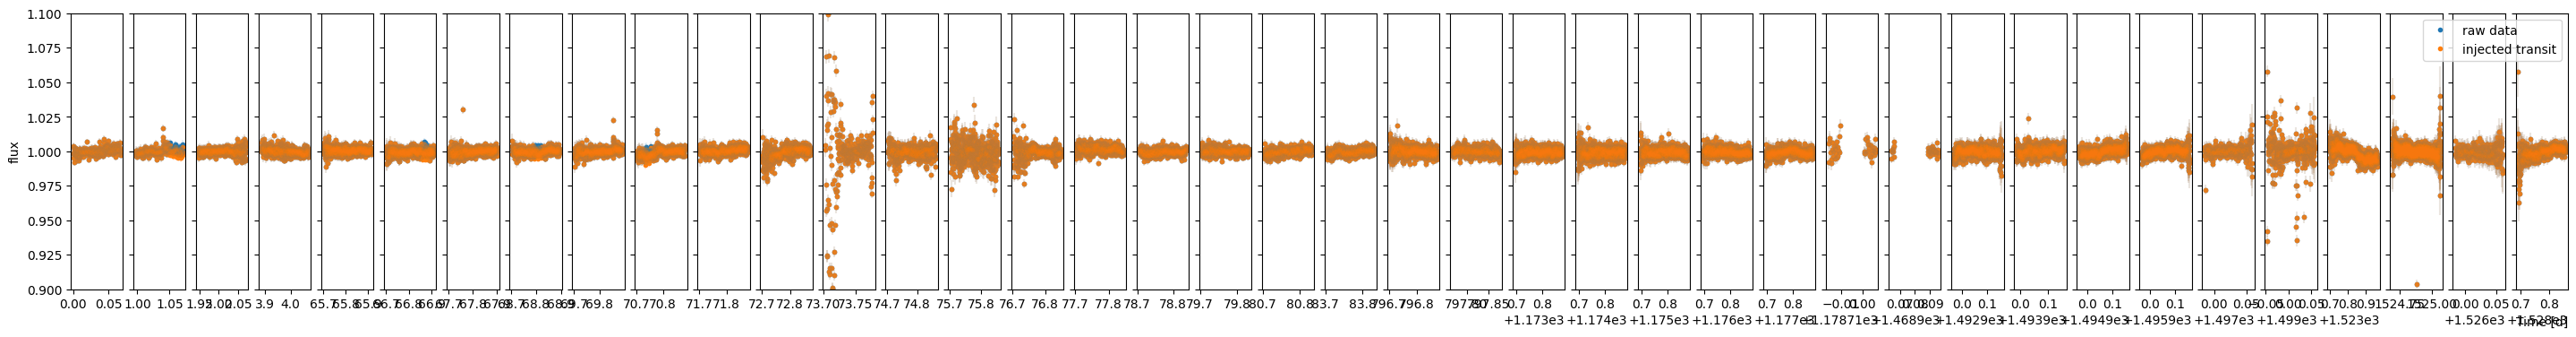

Masking NaN fluxes...
Masking zero fluxes...
Masking cosmic ray hits...



            0.06192224335441638% of data is flagged as cosmics ⚡.
            
Time to clean LC: 7.554258108139038


/Users/catrionamurray/anaconda3/envs/occultence/lib/python3.9/site-packages/numpy/core/fromnumeric.py:784: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



            There are 5 flare candidates with >30.0 s over 3$\sigma$
            


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Time to remove flares: 21.43014907836914
Running BLS Search
Number of Periods Checked:  2921580269
Period:  0.08
Duration:  0.0
Depth:  0.0
Power:  0.0


In [ ]:
x = full_injection_recovery(targ, 
                            # lcs_with_transits=[targ_with_transit],
                                # planets=planets,
                             nfake=5,
                             minimum_planet_radius=0.25 * u.R_earth, 
                             maximum_planet_radius=1 * u.R_earth,
                             minimum_period=0.5 * u.d, 
                             maximum_period=2 * u.d, 
                             ld=[0.3,0.3],
                             clean_kw = {'dust_removal': False, 'bad_weather_removal': False,'cosmics_removal': True,
                                         'threshold_removal':False, 'cosmic_boxsize':0.01, 'cosmic_nsigma':5, 'verbose':True},
                             flare_kw = {'plot':True, 'min_flare_separation':60*u.minute, 'min_flare_duration':30*u.s,
                                         'tbuffer_after':30*u.min, 'n_consecutive_points':2, 'n_points':2, 
                                         'global_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': 5}, 
                                         'local_sc_kw':{'nsigma_upper': 3, 'nsigma_lower': np.inf, 'running_median_boxsize': 0.2},},
                             detrend_method = "gp", 
                             detrend_bin = 10 * u.minute,
                             detrend_kw = {'do_first_sigma_clip': True, 'do_second_sigma_clip': True,
                                           'running_median_boxsize': 0.08, 'nsigma': 3, 'plot': True, 'verbose':True,
                                           'use_uncertainties':False, 'amp_metric':None, 'sqexp_metric':0.1, 
                                           'sqexp_metric_bound':[np.log((0.5*u.hr).to_value('d')), 
                                                                 np.log((np.max(targ.time)-np.min(targ.time)).value)]},
                            bls_kw = {"minimum_period":None, "maximum_period":None, 'minimum_n_transit':2, 'obj':'snr',
                                      'return_all_transits':False, 'transit_durations':[0.01,0.02,0.03,0.04], 'plot':True, 
                                      'verbose': True}, 
                            bls_bin=5 * u.minute,
                            recovery_kw = {'condition_on_epoch':1 * u.hour, 'min_n_transits': 1, 'meet_condition': 'any'},                           
                            verbose=True, plot=True, time_this_process=True)

In [ ]:
# time_to_clean = 19.79s -> now 10s
# time_to_remove_flares = 42.86s -> now 37.47s

In [10]:
lcs, lcs_clean, lcs_gp, lcs_bls, planets_df = x

In [22]:
lcs_bls[1]

[<🌟 Lightcurve secondLC_inject1_clean_sigmaclipped_flaresremoved_bin_bls_0 (302t) 🌟>]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


False


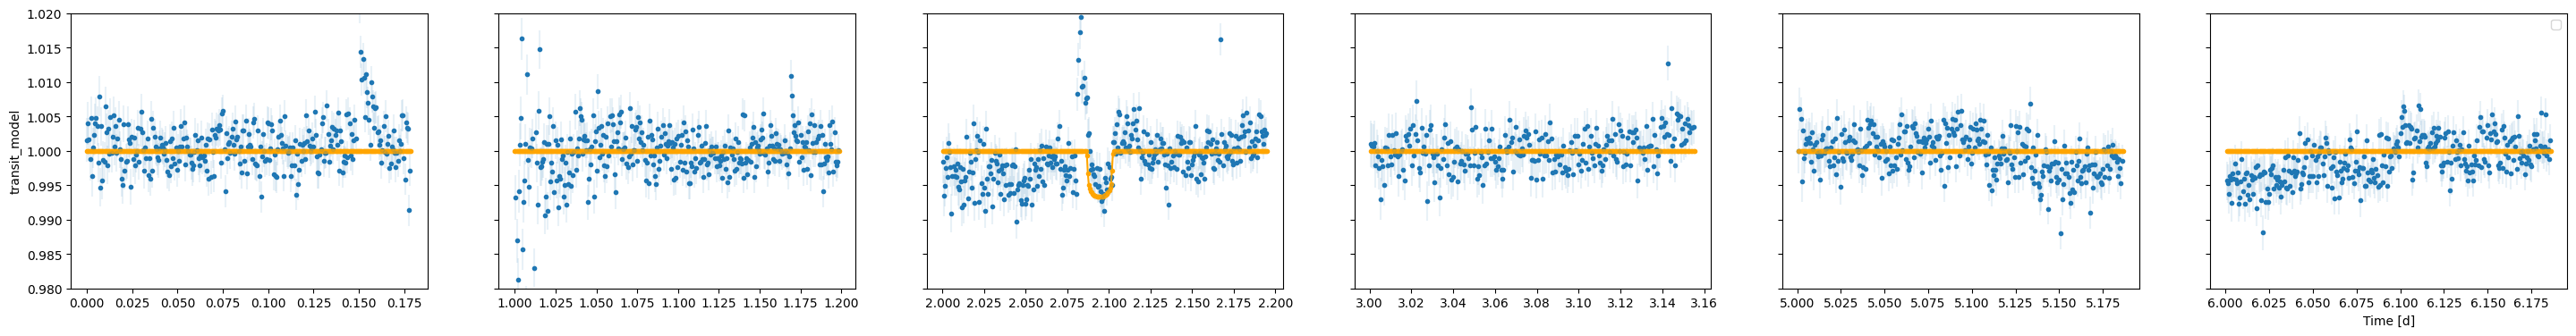

In [31]:
i=4
ax=lcs[i].plot()
lcs[i].plot(quantity="transit_model", color='orange', ax=ax, linestyle="-")
try:
    print(lcs_bls[i][0].metadata['BLS_transits_found'])
except:
    print(False)
    pass

In [45]:
# np.sqrt(planets_df['rec_depth']).values * 
from astropy.units import Quantity
planets_df['r_s'].apply(Quantity)

0    0.1 solRad
1    0.1 solRad
2    0.1 solRad
3    0.1 solRad
4    0.1 solRad
Name: r_s, dtype: object

Text(0.5, 0, 'Planet Radius [R_earth]')

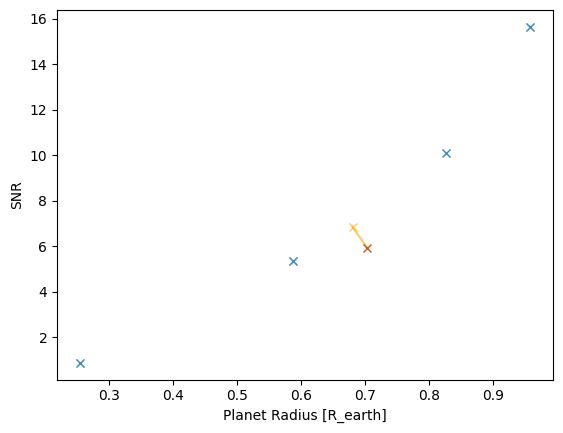

In [46]:
from astropy.units import Quantity

n_points_in_transit = planets_df['duration']/(7.5/(24*60))
lc_noise = 1e-3
rec_r_p = [x.to_value("R_earth") for x in (np.sqrt(planets_df['rec_depth']) * planets_df['r_s'].apply(Quantity)).values]

for r_p, depth, rec, r_p_rec, snr, n in zip(planets_df['r_p'], planets_df['depth'],  planets_df['recovered'],rec_r_p,  planets_df['snr'], n_points_in_transit):
    if rec == 1.0:
        color = "orange"
    else:
        color = "C0"
    if r_p_rec == 0.0:
        r_p_rec = r_p
        snr = depth * np.sqrt(n)/lc_noise
    plt.plot([r_p,r_p_rec], [depth * np.sqrt(n)/lc_noise, snr], 'x-', color=color, alpha=0.6)
    if rec == 1.0:
        plt.plot([r_p_rec], [snr], 'x', color='darkred', alpha=0.5)
plt.ylabel("SNR")
plt.xlabel("Planet Radius [R_earth]")

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


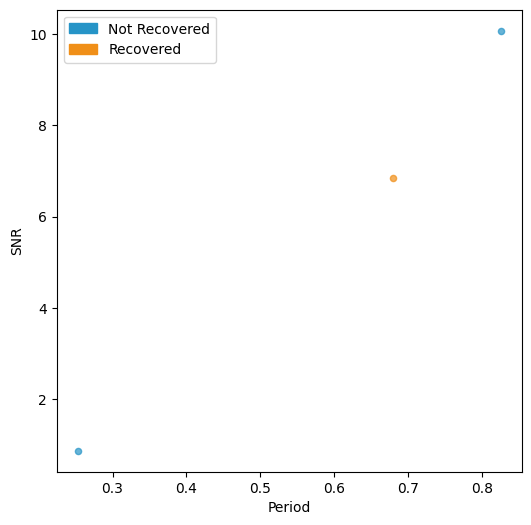

In [33]:
plot_transitparams(x=planets_df['r_p'][planets_df['observed'] == 1.0], 
                   y=planets_df['depth'][planets_df['observed'] == 1.0] * np.sqrt(n_points_in_transit[planets_df['observed'] == 1.0])/lc_noise, 
                   z=planets_df['recovered'][planets_df['observed'] == 1.0], 
                   xlabel="Period", 
                   ylabel="SNR", 
                   zlabel="Detected?", 
                   ylims=[], 
                   yscale='uniform',
                   xscale='uniform', 
                   add_points={}, 
                   pointsize=20,
                   svname="")